In [1]:
import numpy as np
import pandas as pd
from datetime import datetime

import matplotlib.pyplot as plt
import matplotlib as m
from matplotlib.pyplot import figure

import statsmodels
from statsmodels.tsa.api import ExponentialSmoothing, SimpleExpSmoothing
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

from math import sqrt
import sklearn
from sklearn.metrics import mean_squared_error

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore")

In [2]:
%reload_ext watermark
%watermark -a "Matheus  dos Anjos" --iversions

Author: Matheus  dos Anjos

matplotlib : 3.9.2
numpy      : 1.26.4
pandas     : 2.2.2
statsmodels: 0.14.2
sklearn    : 1.5.1



In [3]:
dados_treino = pd.read_csv("C:/Users/conta/OneDrive/Desktop/Análise e Previsão de Séries Temporais/Dados/dataset_treino.csv")
dados_teste = pd.read_csv("C:/Users/conta/OneDrive/Desktop/Análise e Previsão de Séries Temporais/Dados/dataset_teste.csv")

In [4]:
dados_treino.shape

(18288, 3)

In [5]:
dados_teste.shape

(5112, 2)

In [6]:
dados_treino['data'] = pd.to_datetime(dados_treino.data, format = '%d-%m-%Y %H:%M')

In [7]:
dados_teste['data'] = pd.to_datetime(dados_treino.data, format = '%d-%m-%Y %H:%M')

In [8]:
dados_treino.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18288 entries, 0 to 18287
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   id               18288 non-null  int64         
 1   data             18288 non-null  datetime64[ns]
 2   consumo_energia  18288 non-null  int64         
dtypes: datetime64[ns](1), int64(2)
memory usage: 428.8 KB


In [9]:
dados_teste.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5112 entries, 0 to 5111
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   id      5112 non-null   int64         
 1   data    5112 non-null   datetime64[ns]
dtypes: datetime64[ns](1), int64(1)
memory usage: 80.0 KB


In [10]:
dados_treino.index = dados_treino['data']

In [11]:
dados_treino.drop('id', axis = 1, inplace=True)

In [12]:
dados_treino.drop('data', axis = 1, inplace=True)

In [13]:
target = dados_treino['consumo_energia']

In [14]:
dados_treino.head()

,consumo_energia
data,
2020-08-25 00:00:00,8
2020-08-25 01:00:00,2
2020-08-25 02:00:00,6
2020-08-25 03:00:00,2
2020-08-25 04:00:00,2


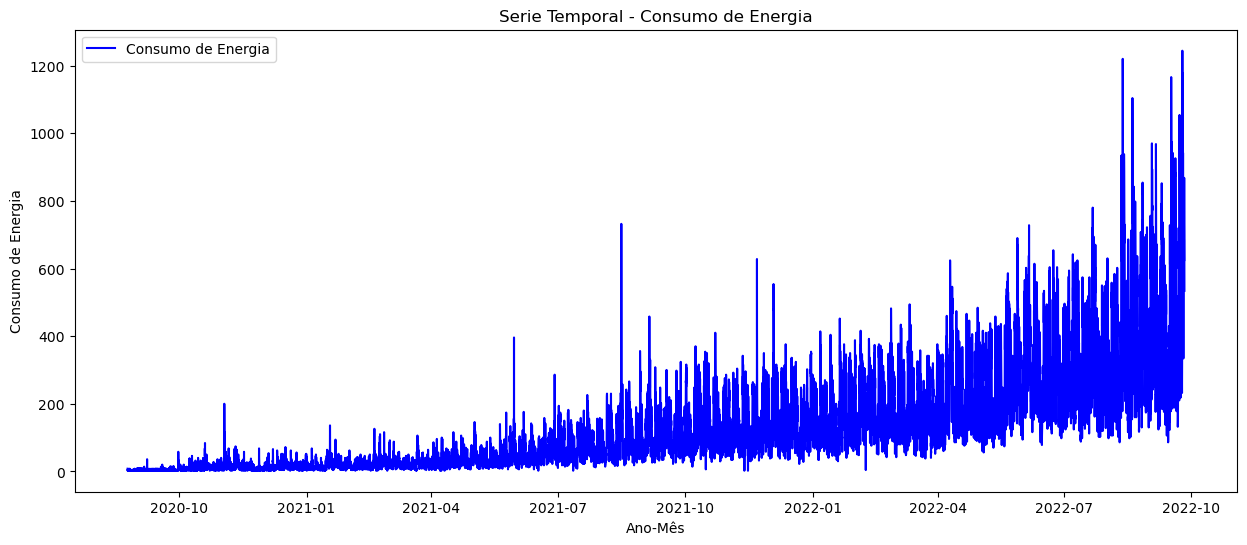

In [15]:
figure(figsize = (15, 6))
plt.title("Serie Temporal - Consumo de Energia")
plt.plot(target, label = 'Consumo de Energia', color = 'blue')
plt.xlabel("Ano-Mês")
plt.ylabel('Consumo de Energia')
plt.legend(loc='best')

In [16]:
df_treino = dados_treino.iloc[0:16057]
df_valid = dados_treino.iloc[16058:]

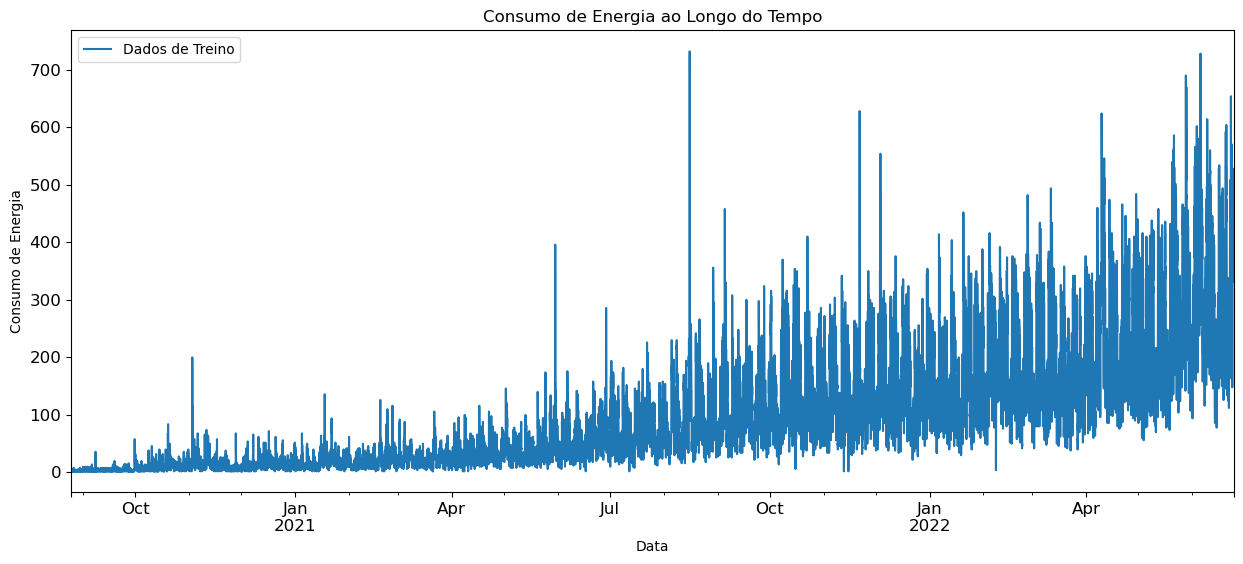

In [17]:
figure(figsize = (15, 6))
df_treino.consumo_energia.plot(title = 'Consumo de Energia ao Longo do Tempo',
                               fontsize = 12,
                               label = 'Dados de Treino')
plt.xlabel('Data')
plt.ylabel('Consumo de Energia')
plt.legend(loc = 'best')
plt.show()

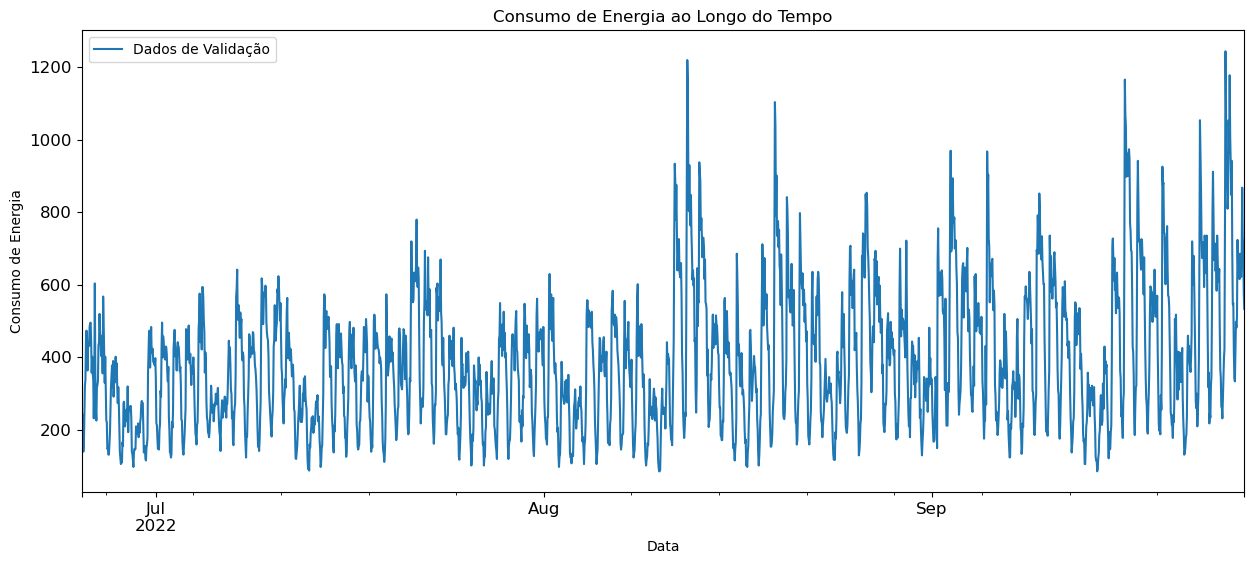

In [18]:
figure(figsize = (15, 6))
df_valid.consumo_energia.plot(title = 'Consumo de Energia ao Longo do Tempo',
                               fontsize = 12,
                               label = 'Dados de Validação')
plt.xlabel('Data')
plt.ylabel('Consumo de Energia')
plt.legend(loc = 'best')
plt.show()

In [19]:
def testa_estacionaridade(serie):
    
    from statsmodels.tsa.stattools import adfuller
    
    # Calcula estatísticas móveis
    rolmean = serie.rolling(window = 12).mean()
    rolstd = serie.rolling(window = 12).std()

    # Plot das estatísticas móveis
    orig = plt.plot(serie, color = 'blue', label = 'Original')
    mean = plt.plot(rolmean, color = 'red', label = 'Média Móvel')
    std = plt.plot(rolstd, color = 'black', label = 'Desvio Padrão')
    
    # Plot
    plt.legend(loc = 'best')
    plt.title('Estatísticas Móveis - Média e Desvio Padrão')
    plt.show()
    
    # Teste Dickey-Fuller:
    # Print
    print('\nResultado do Teste Dickey-Fuller:\n')

    # Teste
    dfteste = adfuller(serie, autolag = 'AIC')

    # Formatando a saída
    dfsaida = pd.Series(dfteste[0:4], index = ['Estatística do Teste',
                                               'Valor-p',
                                               'Número de Lags Consideradas',
                                               'Número de Observações Usadas'])

    # Loop por cada item da saída do teste
    for key, value in dfteste[4].items():
        dfsaida['Valor Crítico (%s)'%key] = value

    # Print
    print (dfsaida)
    
    # Testa o valor-p
    print ('\nConclusão:')
    if dfsaida[1] > 0.05:
        print('\nO valor-p é maior que 0.05 e, portanto, não temos evidências para rejeitar a hipótese nula.')
        print('Essa série provavelmente não é estacionária.')
    else:
        print('\nO valor-p é menor que 0.05 e, portanto, temos evidências para rejeitar a hipótese nula.')
        print('Essa série provavelmente é estacionária.')

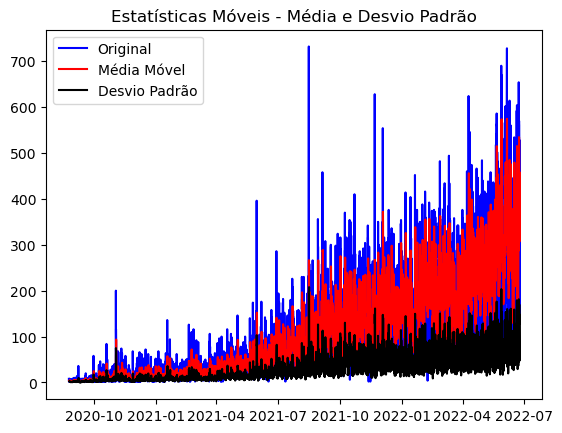


Resultado do Teste Dickey-Fuller:

Estatística do Teste               -5.038033
Valor-p                             0.000019
Número de Lags Consideradas        43.000000
Número de Observações Usadas    16013.000000
Valor Crítico (1%)                 -3.430758
Valor Crítico (5%)                 -2.861721
Valor Crítico (10%)                -2.566866
dtype: float64

Conclusão:

O valor-p é menor que 0.05 e, portanto, temos evidências para rejeitar a hipótese nula.
Essa série provavelmente é estacionária.


In [20]:
testa_estacionaridade(df_treino)

In [21]:
type(df_treino)

pandas.core.frame.DataFrame

In [22]:
array_consumo_energia_treino = np.asarray(df_treino.consumo_energia)

In [23]:
type(array_consumo_energia_treino)

numpy.ndarray

In [24]:
array_consumo_energia_treino.shape

(16057,)

In [25]:
df_valid_cp = df_valid.copy()

In [26]:
df_valid_cp['previsao_naive'] = array_consumo_energia_treino[len(array_consumo_energia_treino) - 1]

In [27]:
df_valid_cp[['consumo_energia', 'previsao_naive']].head()

,consumo_energia,previsao_naive
data,,
2022-06-25 02:00:00,218,332
2022-06-25 03:00:00,244,332
2022-06-25 04:00:00,168,332
2022-06-25 05:00:00,140,332
2022-06-25 06:00:00,156,332


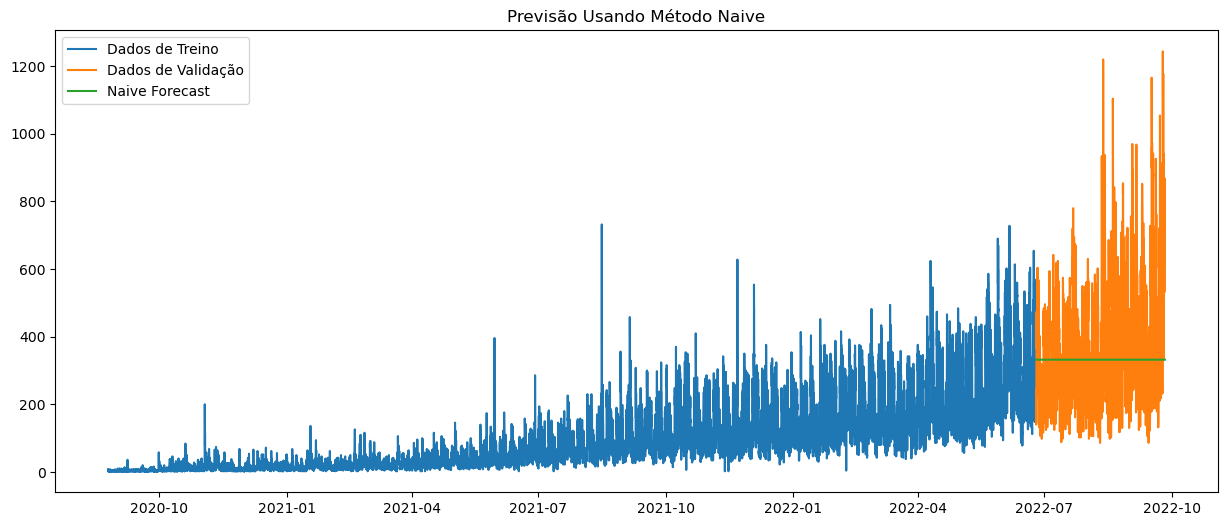

In [28]:
figure(figsize = (15, 6))
plt.title('Previsão Usando Método Naive')
plt.plot(df_treino.index, df_treino['consumo_energia'], label = 'Dados de Treino')
plt.plot(df_valid_cp.index, df_valid['consumo_energia'], label = "Dados de Validação")
plt.plot(df_valid_cp.index, df_valid_cp['previsao_naive'], label = 'Naive Forecast')
plt.legend(loc = 'best')
plt.show()

In [29]:
y_true = df_valid_cp.consumo_energia
y_pred = df_valid_cp.previsao_naive

In [30]:
metrica_rmse = sqrt(mean_squared_error(y_true, y_pred))
print(metrica_rmse)

195.06210118417584


In [31]:
modelo_v1 = SimpleExpSmoothing(array_consumo_energia_treino).fit(smoothing_level = 0.2, optimized = True)

In [32]:
df_valid['previsoes_v1'] = modelo_v1.forecast(len(df_valid))

In [33]:
df_valid[['consumo_energia', 'previsoes_v1']].head()

,consumo_energia,previsoes_v1
data,,
2022-06-25 02:00:00,218,395.388938
2022-06-25 03:00:00,244,395.388938
2022-06-25 04:00:00,168,395.388938
2022-06-25 05:00:00,140,395.388938
2022-06-25 06:00:00,156,395.388938


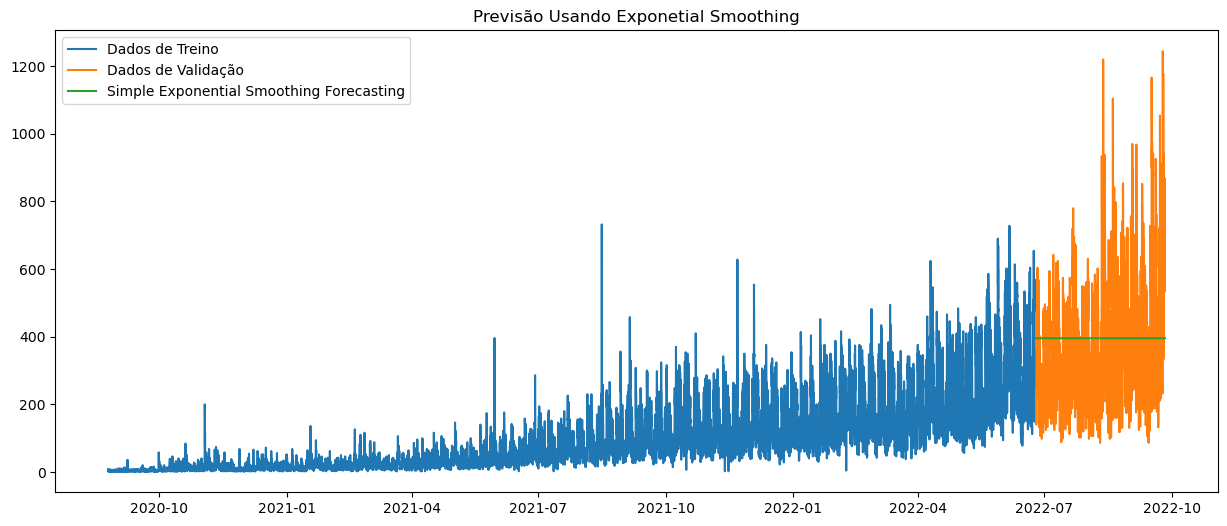

In [34]:
figure(figsize = (15, 6))
plt.title("Previsão Usando Exponetial Smoothing")
plt.plot(df_treino['consumo_energia'], label = "Dados de Treino")
plt.plot(df_valid['consumo_energia'], label = "Dados de Validação")
plt.plot(df_valid['previsoes_v1'], label = "Simple Exponential Smoothing Forecasting")
plt.legend(loc = 'best')
plt.show()

In [35]:
y_true2 = df_valid.consumo_energia
y_pred2 = df_valid.previsoes_v1

In [36]:
metrica_rmse2 = sqrt(mean_squared_error(y_true2, y_pred2))
print(metrica_rmse2)

186.52867297329848


In [37]:
modelo_v2 = ExponentialSmoothing(np.asarray(df_treino['consumo_energia']),
                                 trend='additive').fit(smoothing_level=0.9,
                                                       optimized=True)

In [38]:
df_valid.loc[:, 'previsoes_v2'] = modelo_v2.forecast(len(df_valid))

In [39]:
df_valid[['consumo_energia', 'previsoes_v1', 'previsoes_v2']].head()

,consumo_energia,previsoes_v1,previsoes_v2
data,,,
2022-06-25 02:00:00,218,395.388938,337.596236
2022-06-25 03:00:00,244,395.388938,337.681882
2022-06-25 04:00:00,168,395.388938,337.767528
2022-06-25 05:00:00,140,395.388938,337.853174
2022-06-25 06:00:00,156,395.388938,337.938820


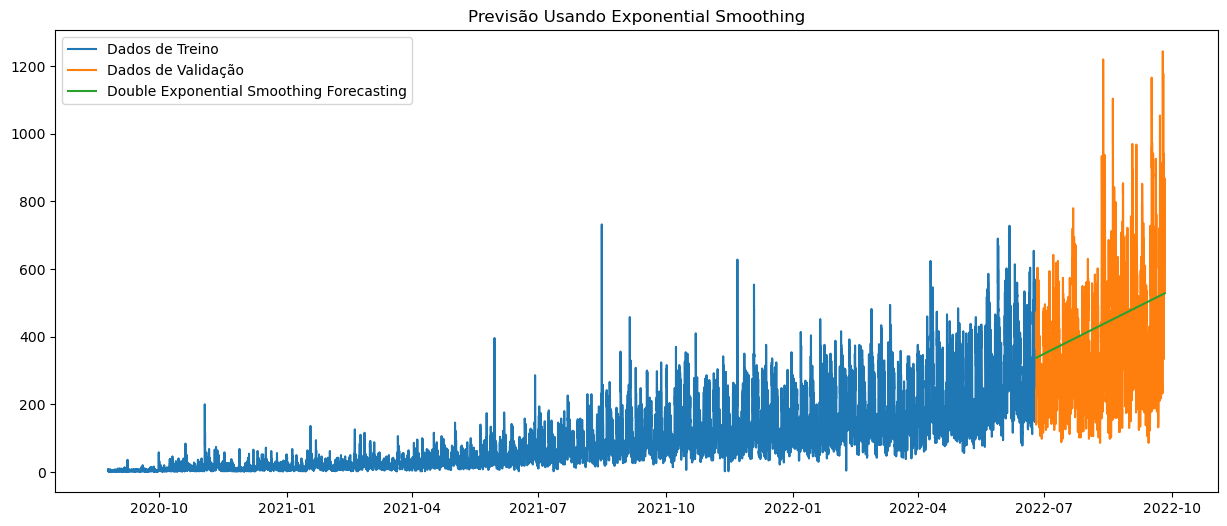

In [40]:
figure(figsize = (15,6))
plt.title('Previsão Usando Exponential Smoothing')
plt.plot(df_treino['consumo_energia'], label='Dados de Treino')
plt.plot(df_valid['consumo_energia'], label='Dados de Validação')
plt.plot(df_valid['previsoes_v2'], label='Double Exponential Smoothing Forecasting')
plt.legend(loc = 'best')
plt.show()

In [41]:
y_true3 = df_valid.consumo_energia
y_pred3 = df_valid.previsoes_v2

In [42]:
metrica_rmse3 = sqrt(mean_squared_error(y_true3, y_pred3))
print(metrica_rmse3)

182.55380116320066
